# Honest-evaluation analysis (CHB-MIT spectral-GC RBF-SVM)

Auto-discovers every `(arm, percentile)` slice in `RESULTS_DIR`, pools event-level
results **duration-weighted**, and reports **all** configs (no selection).

Set `RESULTS_DIR` below to the folder holding both `RESULTS_*.csv` and `SEGMENTS_*.csv`.

In [1]:
import os, re
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 130, "font.size": 10, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.right": False, "axes.spines.top": False})

# folder with BOTH RESULTS_*.csv and SEGMENTS_*.csv (override via env var if needed)
RESULTS_DIR = Path(os.environ.get("RESULTS_DIR", "../RESULTS"))
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

SHOEB  = dict(sens=0.96, fph=0.08)   # Shoeb & Guttag 2010 reference
REF_CG = (10.0, "scale")             # pre-specified illustrative config (C, gamma) for per-patient panels
print("reading from:", RESULTS_DIR.resolve())

reading from: C:\Users\ritaw\Desktop\RESULTS


In [2]:
# auto-discover slices: pair each RESULTS_*.csv with its SEGMENTS_*.csv, parse arm + pct
_pat = re.compile(r"RESULTS_(0|10K)_(\d+)", re.I)
CANDIDATES = {}
for rf in sorted(RESULTS_DIR.glob("RESULTS_*.csv")):
    m = _pat.search(rf.name)
    if not m:
        print("skip (unparseable):", rf.name); continue
    arm, pct = m.group(1), int(m.group(2))
    sf = rf.with_name(rf.name.replace("RESULTS_", "SEGMENTS_"))
    if not sf.exists():
        print("skip (no SEGMENTS):", rf.name); continue
    label = f"Arm{'A' if arm=='0' else 'B'}_{pct}pct"     # ArmA=seizure-records-only, ArmB=all-records 10k
    CANDIDATES[label] = (arm, pct, rf, sf)

assert CANDIDATES, f"No RESULTS_*.csv found in {RESULTS_DIR.resolve()} -- fix RESULTS_DIR"
print("discovered:", list(CANDIDATES))

skip (unparseable): RESULTS_LEAKY.csv
discovered: ['ArmA_10pct', 'ArmB_10pct', 'ArmB_5pct']


In [3]:
def ref_config(res):
    m = res[(res.C == REF_CG[0]) & (res.gamma.astype(str) == REF_CG[1])]
    return m.config.iloc[0]

def pool_by_config(res):
    """Duration-weighted event-level pooling per config."""
    def _agg(d):
        return pd.Series({
            "sensitivity": d.TP.sum() / max(d.TP.sum() + d.FN.sum(), 1),
            "FP/h":        d.FP.sum() / d.total_length_hours.sum(),
            "median_latency": np.nanmedian(d.latency_median),
            "mean_auc":    d.mean_fold_roc_auc.mean(),
            "mean_ap":     d.mean_fold_ap.mean(),
            "n_pat_0detect": int((d.n_detected == 0).sum()),
        })
    return (res.groupby(["config", "C", "gamma", "percentile"])
               .apply(_agg, include_groups=False).reset_index())

In [4]:
def report_all_table(res, label):
    t = pool_by_config(res).sort_values(["C", "gamma"]).round(3)
    t.to_csv(OUT/f"table_reportall_{label}.csv", index=False)
    return t

def per_patient_table(res, label, cfg):
    cols = ["patient","total_length_hours","TP","FP","FN","sensitivity",
            "FP/hour","latency_median","mean_fold_roc_auc","mean_fold_ap"]
    t = res[res.config == cfg][cols].round(3)
    t.to_csv(OUT/f"table_perpatient_{label}_{cfg}.csv", index=False)
    return t

In [5]:
def fig_failure_modes(res, label, cfg):
    d = res[res.config == cfg]
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
    for a, (ycol, ylab, ref) in zip(ax, [("sensitivity","event sensitivity",SHOEB["sens"]),
                                         ("FP/hour","FP / hour",SHOEB["fph"])]):
        a.scatter(d.mean_fold_roc_auc, d[ycol], s=45, c="#2b6cb0", zorder=3)
        for _, r in d.iterrows():
            a.annotate(r.patient.replace("chb",""), (r.mean_fold_roc_auc, r[ycol]),
                       fontsize=7, xytext=(3,3), textcoords="offset points")
        a.axhline(ref, ls="--", c="#e53e3e", lw=1)
        a.text(a.get_xlim()[0], ref, " Shoeb", color="#e53e3e", va="bottom", fontsize=8)
        a.set_xlabel("mean fold ROC-AUC"); a.set_ylabel(ylab)
    ax[0].axvline(0.7, ls=":", c="grey")
    ax[0].set_title("discrimination failure  <-|->  non-transfer")
    ax[1].set_title("false-alarm vs discrimination")
    fig.suptitle(f"Per-patient diagnosis  ({label}, {cfg})")
    fig.tight_layout(); fig.savefig(OUT/f"fig_failuremodes_{label}_{cfg}.png"); plt.show()

def fig_seg_vs_event(res, seg, label, cfg):
    ev = res[res.config == cfg].set_index("patient")["sensitivity"]
    sg = (seg[seg.config == cfg].groupby("patient")
          .apply(lambda d: d.tp.sum()/max(d.tp.sum()+d.fn.sum(),1), include_groups=False))
    df = pd.DataFrame({"segment": sg, "event": ev}).dropna().sort_values("segment")
    x = np.arange(len(df))
    fig, a = plt.subplots(figsize=(11, 4))
    a.vlines(x, df.event, df.segment, color="#cbd5e0", zorder=1)
    a.scatter(x, df.segment, label="segment-level", c="#38a169", zorder=3)
    a.scatter(x, df.event,   label="event-level",   c="#e53e3e", zorder=3)
    a.set_xticks(x); a.set_xticklabels([p.replace("chb","") for p in df.index], fontsize=7)
    a.set_ylabel("sensitivity"); a.set_xlabel("patient")
    a.set_title(f"Operating-point transfer drop ({label}, {cfg})"); a.legend()
    fig.tight_layout(); fig.savefig(OUT/f"fig_segvsevent_{label}_{cfg}.png"); plt.show()

def fig_grid_heatmap(res, label):
    p = pool_by_config(res)
    order = ["scale","0.01","0.001","0.0001"]
    p["gamma"] = pd.Categorical(p.gamma.astype(str), order, ordered=True)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
    for a, metric, cmap in zip(ax, ["sensitivity","FP/h"], ["viridis","magma_r"]):
        m = p.pivot_table(index="C", columns="gamma", values=metric, observed=True)
        im = a.imshow(m.values, cmap=cmap, aspect="auto")
        a.set_xticks(range(len(m.columns))); a.set_xticklabels(m.columns, rotation=45, ha="right")
        a.set_yticks(range(len(m.index)));   a.set_yticklabels(m.index)
        a.set_xlabel("gamma"); a.set_ylabel("C"); a.set_title(metric)
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                a.text(j, i, f"{m.values[i,j]:.2f}", ha="center", va="center", fontsize=8, color="w")
        fig.colorbar(im, ax=a, fraction=.046)
    fig.suptitle(f"C x gamma grid ({label})"); fig.tight_layout()
    fig.savefig(OUT/f"fig_grid_{label}.png"); plt.show()

In [6]:
def master_grid(pools):
    rows = []
    for label, (arm, pct, p) in pools.items():
        q = p.copy(); q.insert(0, "arm", arm); q.insert(1, "pct", pct); q.insert(2, "slice", label)
        rows.append(q)
    g = pd.concat(rows).sort_values(["arm","pct","C","gamma"]).round(3)
    g.to_csv(OUT/"table_master_grid.csv", index=False)
    return g

def fig_slice_envelope(pools):
    fig, a = plt.subplots(figsize=(7.5, 5.5))
    cols = {"ArmA_10pct":"#2b6cb0","ArmB_10pct":"#38a169","ArmA_5pct":"#d69e2e","ArmB_5pct":"#9f7aea"}
    for label, (arm, pct, p) in pools.items():
        a.scatter(p["FP/h"], p.sensitivity, s=55, c=cols.get(label,"#444"),
                  label=label, edgecolor="w", zorder=3)
    a.scatter(SHOEB["fph"], SHOEB["sens"], marker="*", s=320, c="#e53e3e",
              edgecolor="k", zorder=4, label="Shoeb & Guttag 2010")
    a.set_xlabel("FP / hour (pooled)"); a.set_ylabel("event sensitivity (pooled)")
    a.set_title("Operating envelope: all configs x slices vs benchmark"); a.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(OUT/"fig_operating_envelope.png"); plt.show()

def paired_delta(resA, resB, nameA, nameB):
    """Per-patient delta(sens, FP/h), B-A, at the reference (C, gamma)."""
    cA, cB = ref_config(resA), ref_config(resB)
    ka = resA[resA.config == cA].set_index("patient")
    kb = resB[resB.config == cB].set_index("patient")
    j = ka.join(kb, lsuffix="_A", rsuffix="_B", how="inner")
    d = pd.DataFrame({"d_sens": j["sensitivity_B"] - j["sensitivity_A"],
                      "d_fph":  j["FP/hour_B"]    - j["FP/hour_A"]}).sort_index()
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    for a, col, ttl in zip(ax, ["d_sens","d_fph"],
                           [f"d sensitivity  ({nameB} - {nameA})", f"d FP/h  ({nameB} - {nameA})"]):
        a.barh([p.replace("chb","") for p in d.index], d[col],
               color=np.where(d[col] >= 0, "#38a169", "#e53e3e"))
        a.axvline(0, c="k", lw=.8); a.set_title(ttl); a.tick_params(labelsize=7)
    fig.suptitle(f"Paired contrast at C={REF_CG[0]}, gamma={REF_CG[1]}")
    fig.tight_layout(); fig.savefig(OUT/f"fig_delta_{nameA}_vs_{nameB}.png"); plt.show()
    d.round(3).to_csv(OUT/f"table_delta_{nameA}_vs_{nameB}.csv")
    return d.d_sens.median(), d.d_fph.median()

--- ArmA_10pct (ref config I10) ---


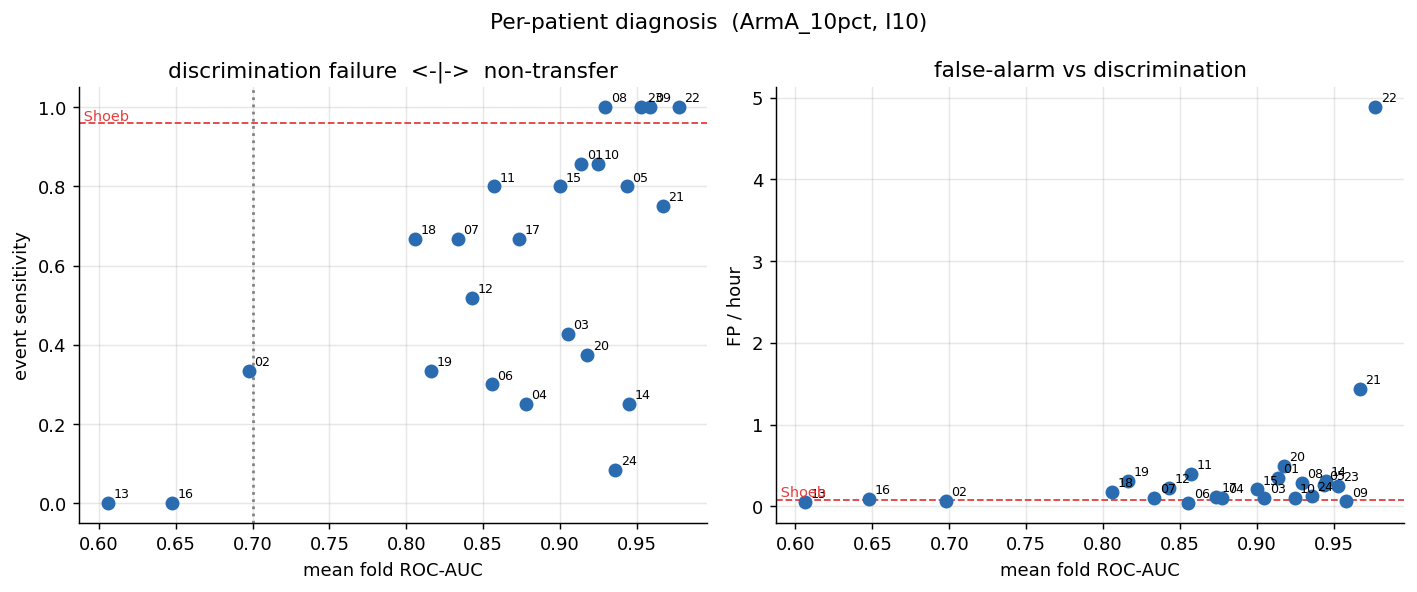

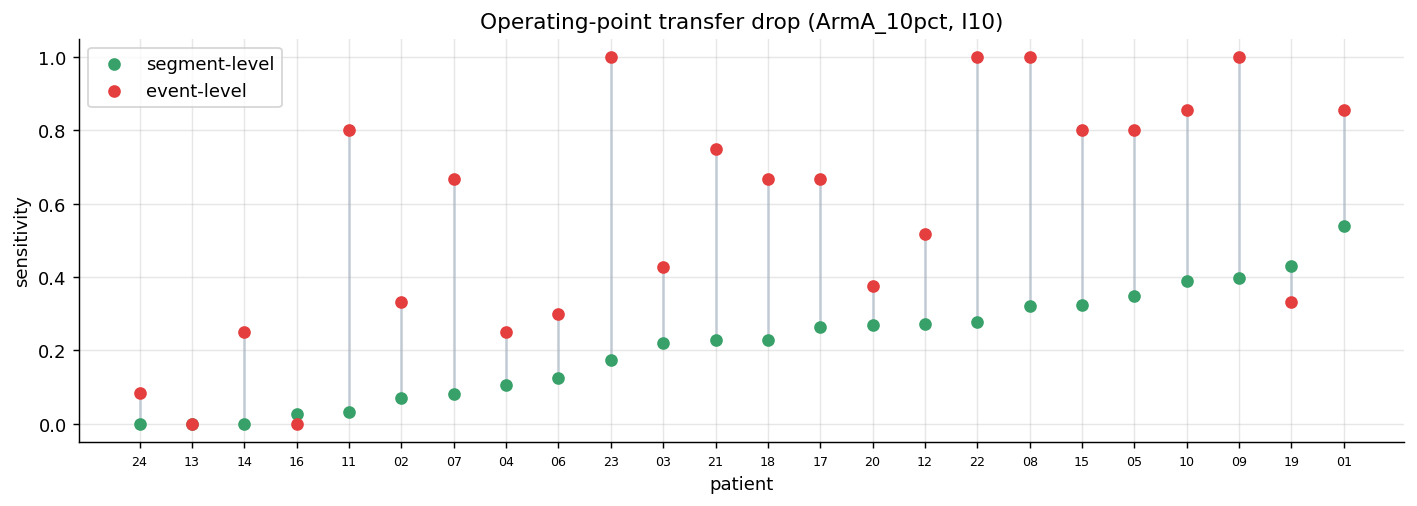

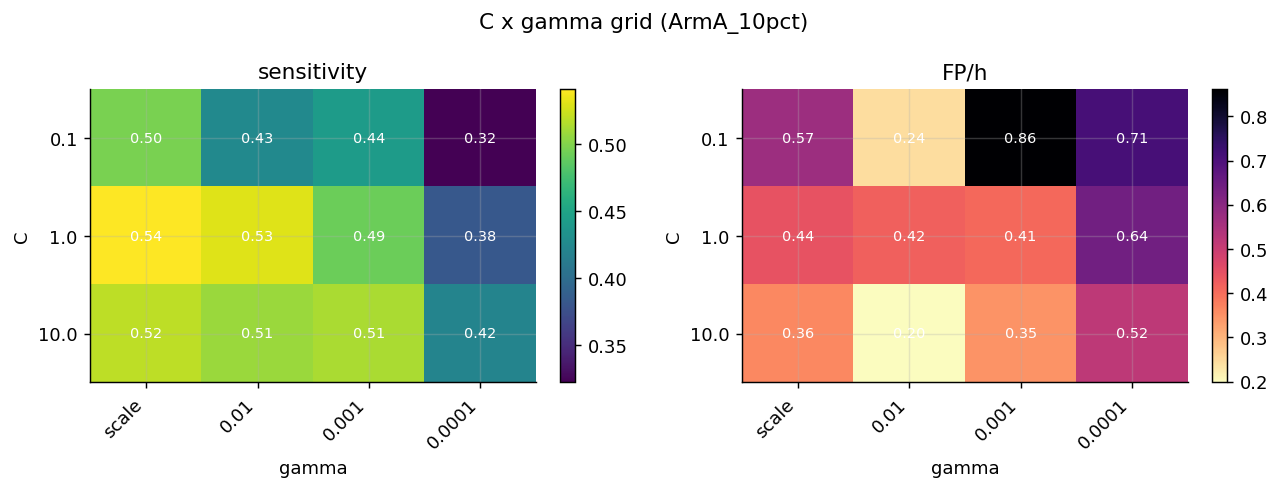

--- ArmB_10pct (ref config I10) ---


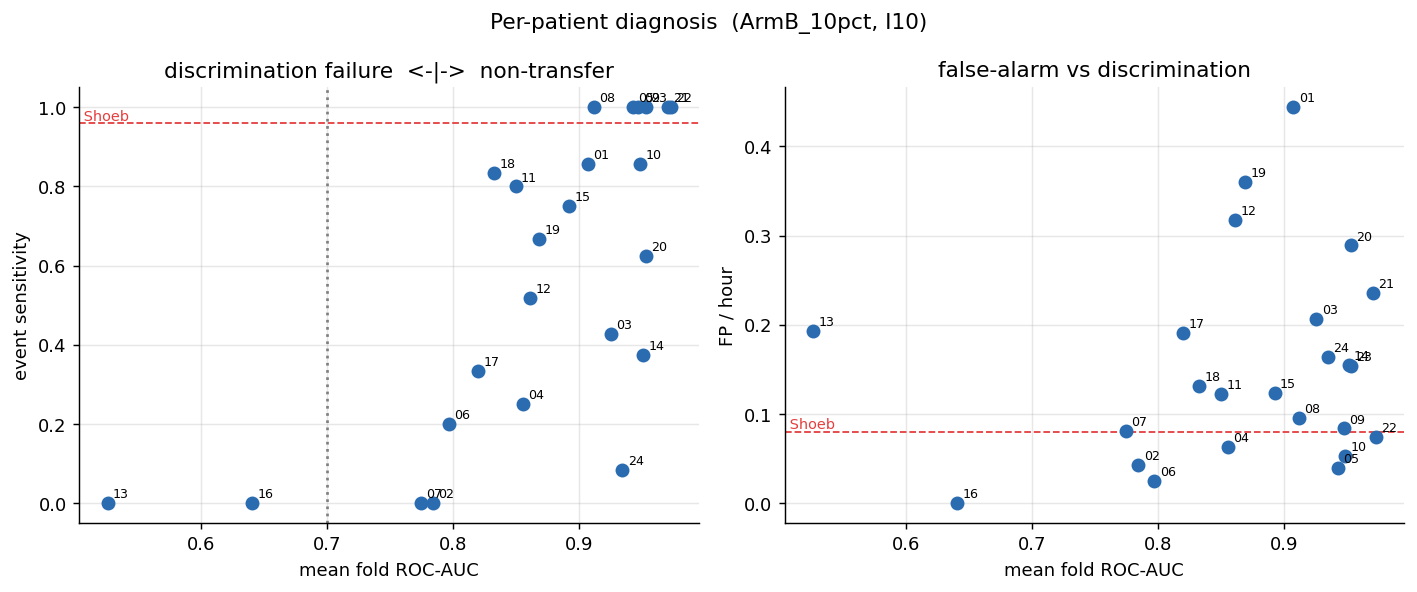

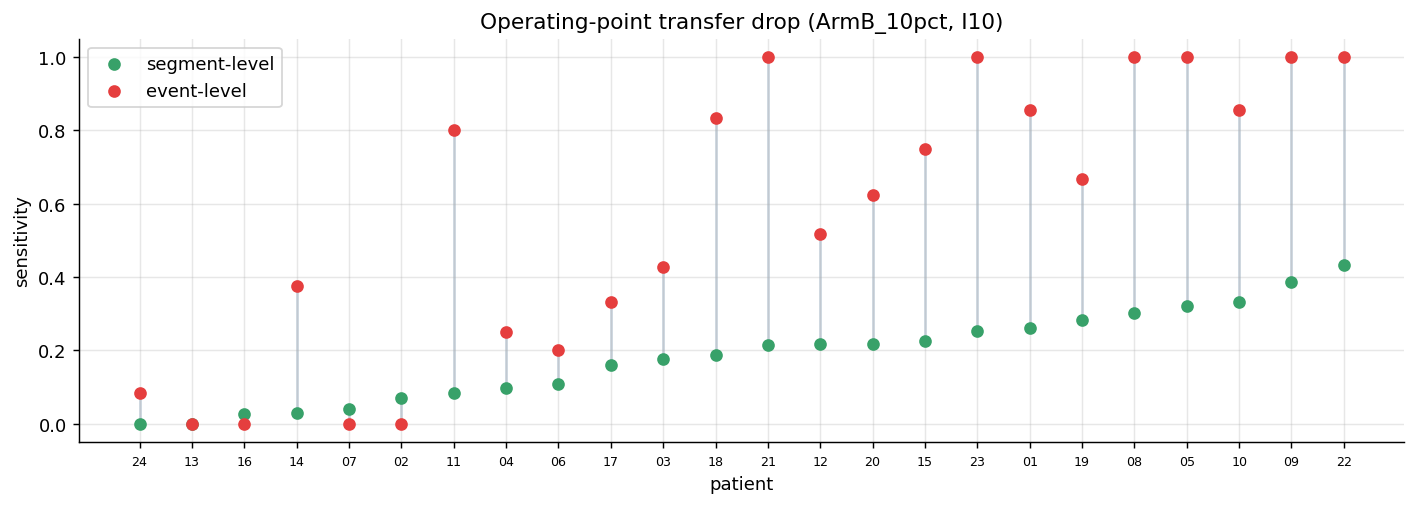

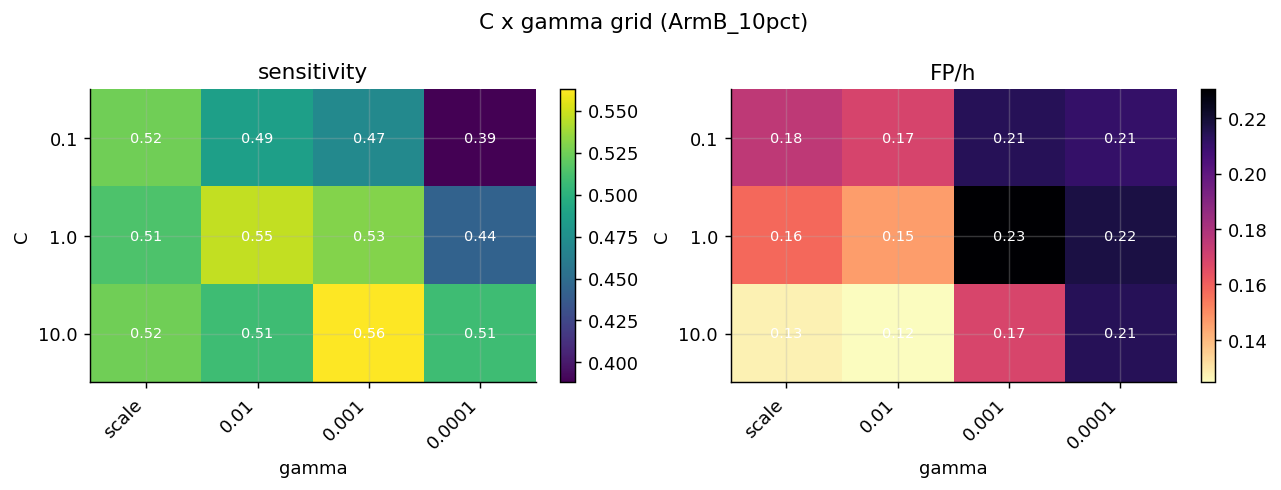

--- ArmB_5pct (ref config I5) ---


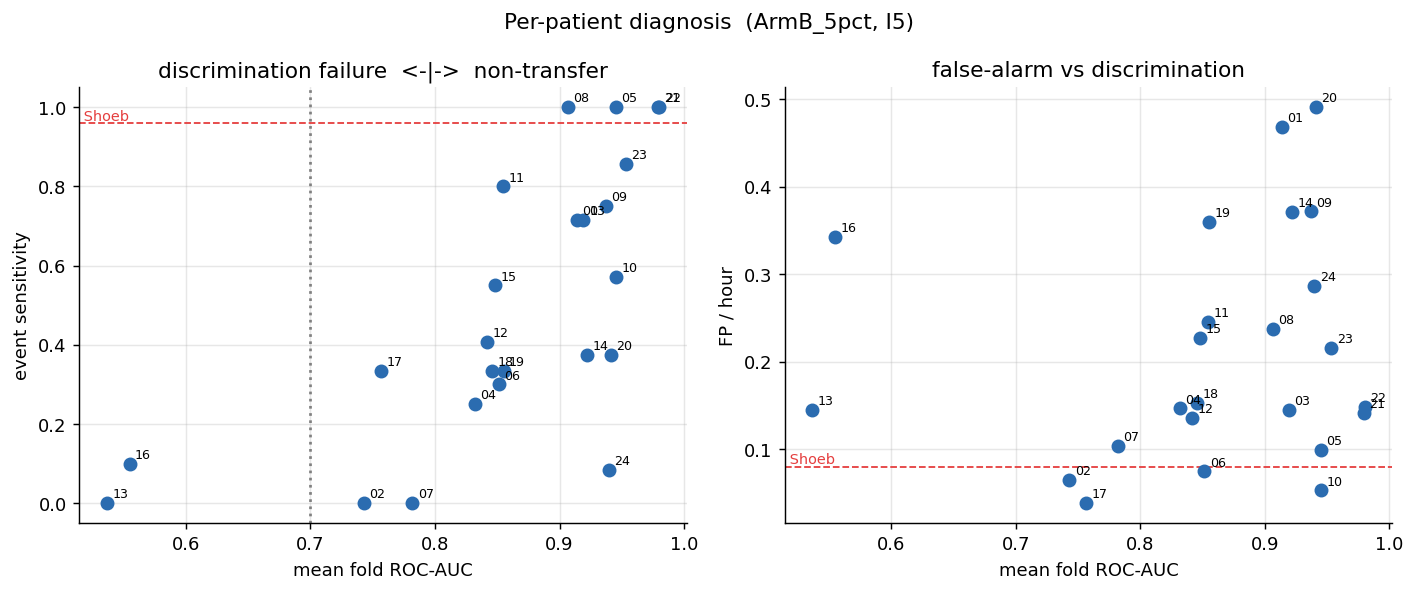

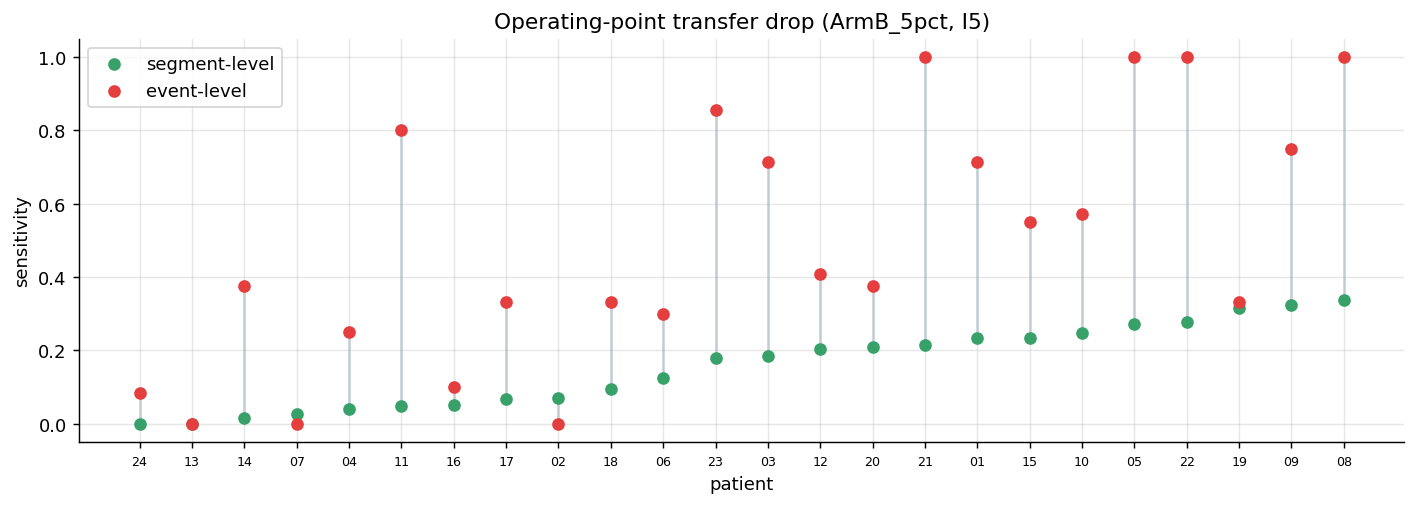

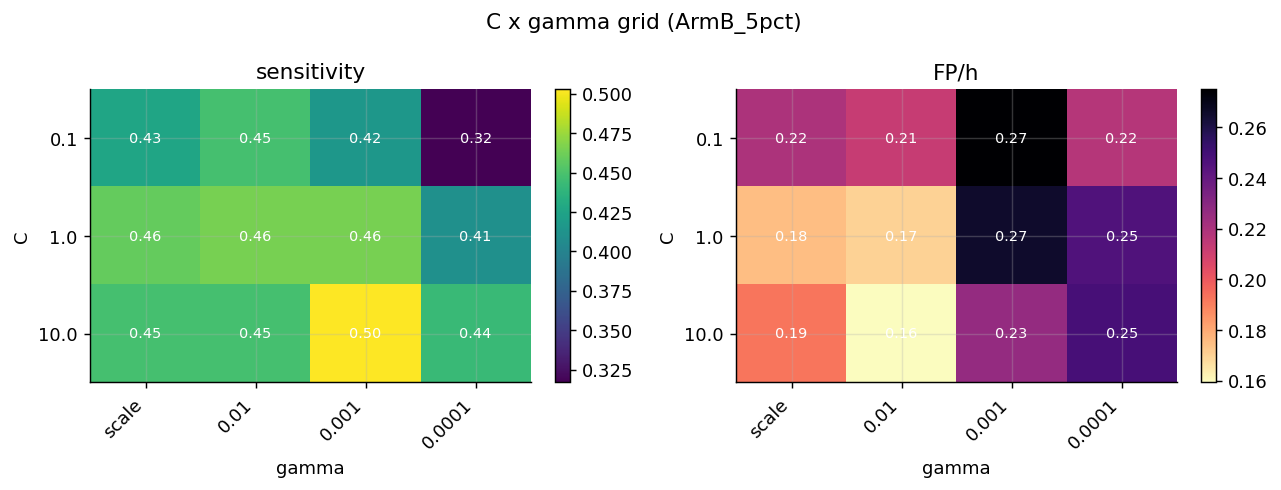

In [7]:
loaded, pools = {}, {}
for label, (arm, pct, rp, sp) in CANDIDATES.items():
    res, seg = pd.read_csv(rp), pd.read_csv(sp)
    cfg = ref_config(res)
    loaded[label] = (arm, pct, res, seg)
    pools[label]  = (arm, pct, pool_by_config(res))
    print(f"--- {label} (ref config {cfg}) ---")
    report_all_table(res, label)
    per_patient_table(res, label, cfg)
    fig_failure_modes(res, label, cfg)
    fig_seg_vs_event(res, seg, label, cfg)
    fig_grid_heatmap(res, label)

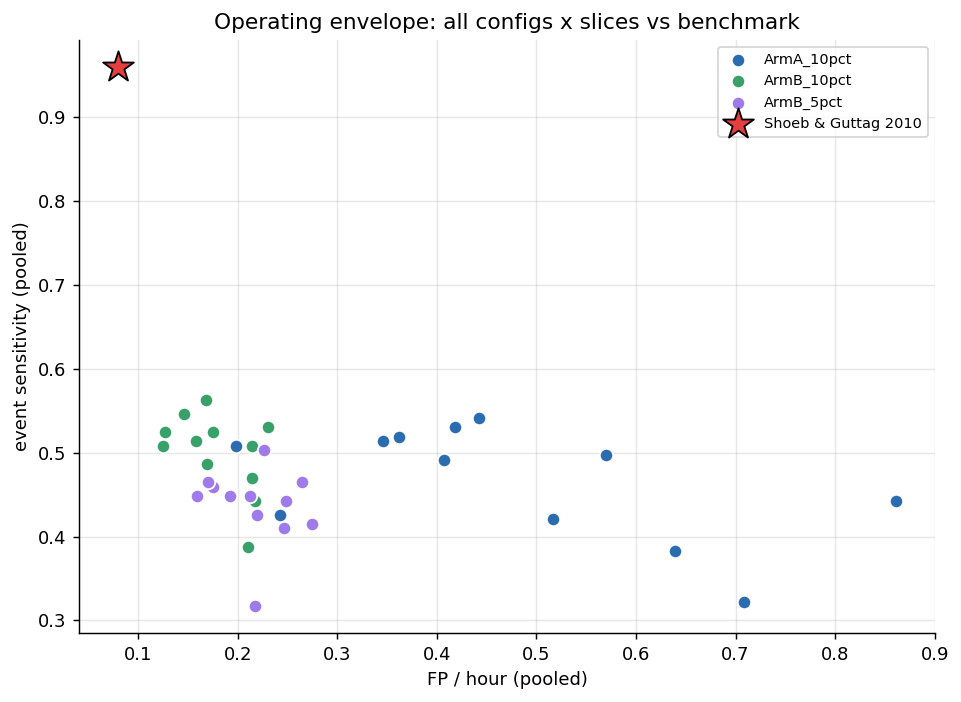

,slice,C,gamma,sensitivity,FP/h,mean_auc,median_latency
3,ArmA_10pct,0.1,0.0001,0.322,0.708,0.875,25.500
2,ArmA_10pct,0.1,0.001,0.443,0.861,0.889,28.125
1,ArmA_10pct,0.1,0.01,0.426,0.243,0.873,26.000
0,ArmA_10pct,0.1,scale,0.497,0.570,0.882,30.375
7,ArmA_10pct,1.0,0.0001,0.383,0.639,0.888,27.500
6,ArmA_10pct,1.0,0.001,0.492,0.407,0.889,28.500
5,ArmA_10pct,1.0,0.01,0.530,0.419,0.867,28.500
4,ArmA_10pct,1.0,scale,0.541,0.443,0.878,28.500
11,ArmA_10pct,10.0,0.0001,0.421,0.517,0.885,25.500
10,ArmA_10pct,10.0,0.001,0.514,0.346,0.882,28.000


In [8]:
g = master_grid(pools)
fig_slice_envelope(pools)
g[["slice","C","gamma","sensitivity","FP/h","mean_auc","median_latency"]]

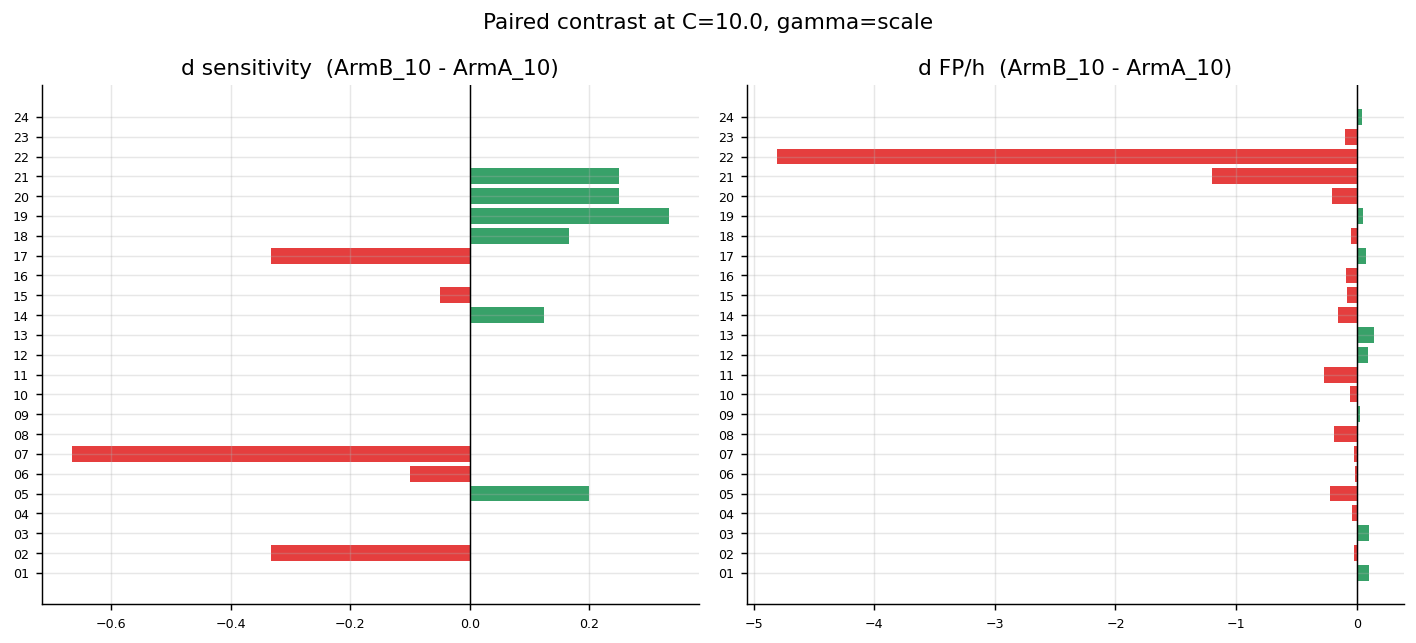

ArmB_10 - ArmA_10:  median d_sens=+0.000  median d_FP/h=-0.041
ArmB_5 - ArmA_5:  SKIPPED (missing slice)


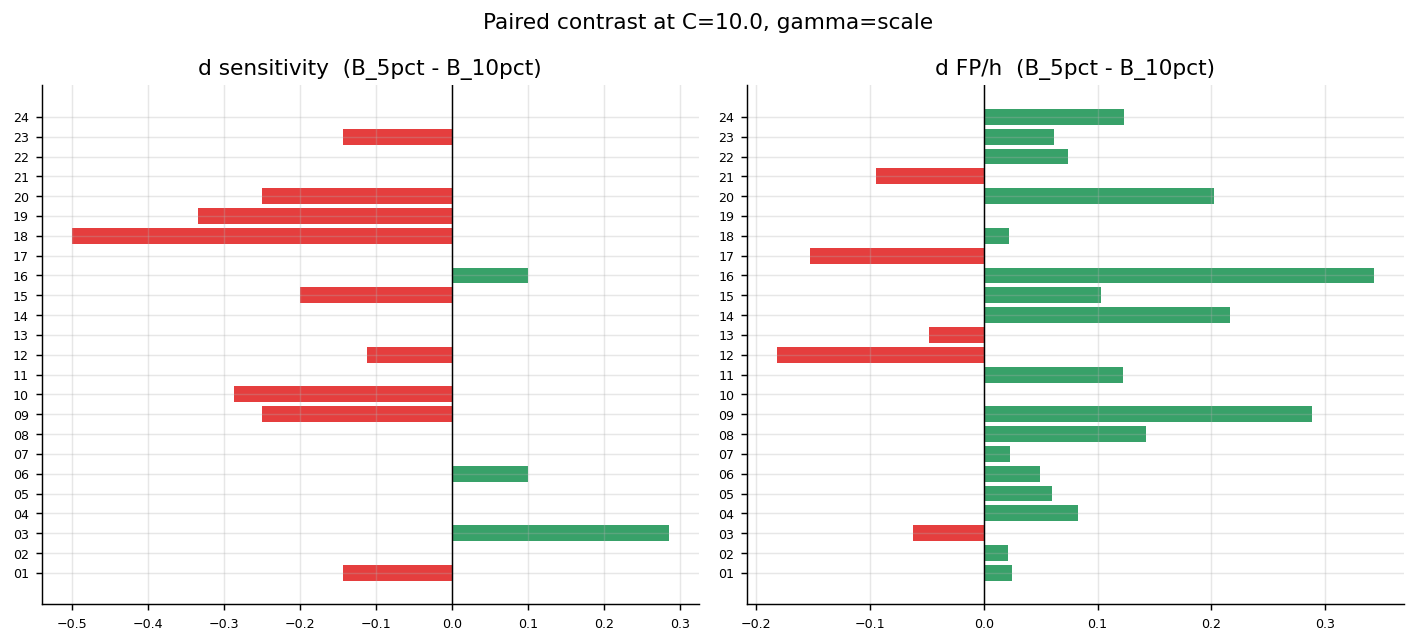

B_5pct - B_10pct:  median d_sens=+0.000  median d_FP/h=+0.055
A_5pct - A_10pct:  SKIPPED (missing slice)

all tables + figures in C:\Users\ritaw\Desktop\THESIS\outputs


In [9]:
def get(lbl): return loaded[lbl][2] if lbl in loaded else None
contrasts = [("ArmA_10pct","ArmB_10pct","ArmA_10","ArmB_10"),   # negative-sourcing @10%
             ("ArmA_5pct","ArmB_5pct","ArmA_5","ArmB_5"),        # negative-sourcing @5%
             ("ArmB_10pct","ArmB_5pct","B_10pct","B_5pct"),      # feature count, Arm B
             ("ArmA_10pct","ArmA_5pct","A_10pct","A_5pct")]      # feature count, Arm A
for a, b, na, nb in contrasts:
    if get(a) is not None and get(b) is not None:
        ds, df_ = paired_delta(get(a), get(b), na, nb)
        print(f"{nb} - {na}:  median d_sens={ds:+.3f}  median d_FP/h={df_:+.3f}")
    else:
        print(f"{nb} - {na}:  SKIPPED (missing slice)")
print("\nall tables + figures in", OUT.resolve())